<a href="https://colab.research.google.com/github/novakai-one/claude-ai-demo/blob/main/notebooks/fields/10_generative_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Field 10 · Generative models · taste project*

# How can a model create new things that look real?

> **In short**
>
> **How can a model create new things that look real?**
>
> Take real examples and add noise to them, step by step, until only noise is left. Train a network to undo one small step. Then start from fresh noise and undo every step: out comes a new example.

## Where you'll end up

By the end you will have built:

1. **A Gaussian generator** and seen why it fails on curved data.
2. **An autoencoder** that finds the spiral's one-dimensional shape and generates from it.
3. **A diffusion model**, trained from scratch, that turns noise into new spiral points (below), plus the same sampling with the Hugging Face `diffusers` library.

Runs on a CPU in about two minutes.

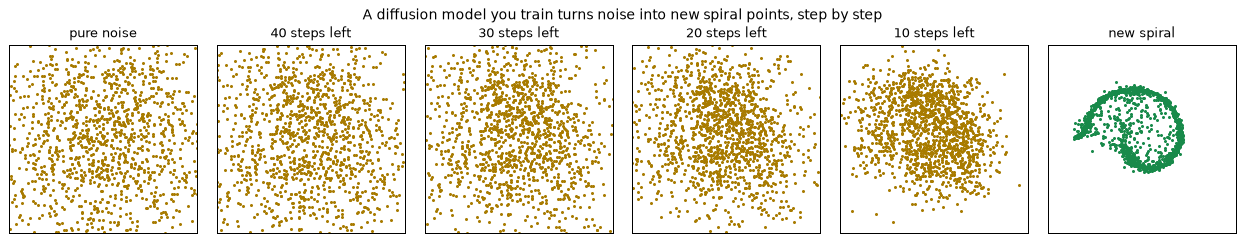

## How to use this notebook

- Run each grey code cell with **Shift + Enter**, top to bottom.
- 🤔 **Predict first** boxes ask you to guess before you run. The answer is one click away.
- 🐍 **Python notes** explain Python as it comes up.
- Exercise solutions are in collapsed cells. In Colab, double-click a solution's title to open it.

In [1]:
%pip install -q diffusers   # used once, in section 5

Note: you may need to restart the kernel to use updated packages.


## 1. The problem: new points that look like the old ones

Here are 5,000 points shaped like a spiral. **Make a program that produces new points that also look like they belong to the spiral, without copying the old ones.**

Swap points for photos and this is the question behind image generators. Points are easier to see, and train in seconds.

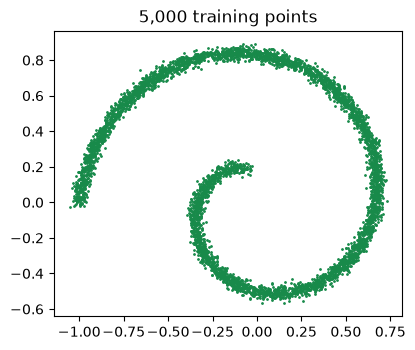

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
rng = np.random.default_rng(0)

def spiral(n, noise=0.02):
    t = np.sqrt(rng.uniform(0.04, 1, n)) * 3 * np.pi          # angle along the spiral
    x = np.stack([t * np.cos(t), t * np.sin(t)], 1) / (3 * np.pi)
    return x + rng.normal(0, noise, x.shape)

data = spiral(5000)

plt.figure(figsize=(4.5, 4.5))
plt.scatter(data[:, 0], data[:, 1], s=1, color="#188a4a")
plt.gca().set_aspect("equal"); plt.title("5,000 training points"); plt.show()

🐍 **Python notes**
- `np.stack([a, b], 1)` puts two lists of numbers side by side as columns: an (n, 2) array of points.
- `rng.normal(0, noise, x.shape)` draws random numbers from a bell curve with average 0 and spread `noise`, one per coordinate.

## 2. The simplest generator: one bell curve

A **Gaussian** (normal) distribution is the bell curve; in 2-D, a blob. It is described by an average point and a spread.
Measure those from the data, then draw new points from the blob.

### 🤔 Predict first

**What will 5,000 points drawn from the best-fitting blob look like?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

**A round-ish cloud** covering the spiral's area, with no spiral in it. A single blob can only make blobs.

</details>

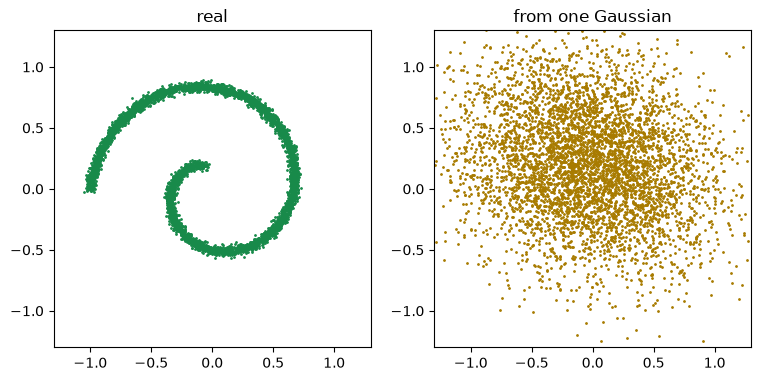

mismatch between real and Gaussian points: 1.803


In [3]:
mean = data.mean(0)
cov = np.cov(data.T)                                    # 2 x 2 spread matrix
blob = rng.multivariate_normal(mean, cov, 5000)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, pts, title, col in [(axes[0], data, "real", "#188a4a"), (axes[1], blob, "from one Gaussian", "#a87b00")]:
    ax.scatter(pts[:, 0], pts[:, 1], s=1, color=col); ax.set_aspect("equal"); ax.set_title(title)
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
plt.show()

def histogram(pts, bins=24):
    h, _, _ = np.histogram2d(pts[:, 0], pts[:, 1], bins=bins, range=[[-1.2, 1.2], [-1.2, 1.2]])
    h = h + 1e-3                                          # avoid log(0)
    return h / h.sum()

def kl(p, q):
    return float((p * np.log(p / q)).sum())

print(f"mismatch between real and Gaussian points: {kl(histogram(data), histogram(blob)):.3f}")

**What it's called:** that mismatch number is the *KL divergence*: for every small square of the page, compare how often real points land there ($p$) with how often generated ones do ($q$):

$$D_{\text{KL}}(p \,\|\, q) = \sum p \log \frac{p}{q}$$

It is 0 when the two match exactly, and grows when the generator puts points in the wrong places. You will use it to score each generator.

## 3. Find the shape

The spiral is really a **curve**: one number (how far along it) describes each point, plus a little noise.
Train a network to squeeze each point into **one** number and rebuild the point from it. To rebuild well, that number has to mean "how far along the spiral".
Then generate by picking random numbers and rebuilding.

rebuild error: 0.0011


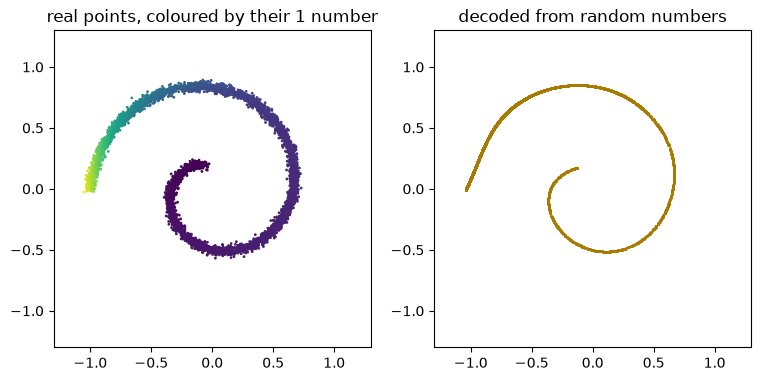

mismatch (KL) for the autoencoder's points: 1.408


In [4]:
torch.manual_seed(0)
encoder = nn.Sequential(nn.Linear(2, 64), nn.SiLU(), nn.Linear(64, 64), nn.SiLU(), nn.Linear(64, 1))
decoder = nn.Sequential(nn.Linear(1, 64), nn.SiLU(), nn.Linear(64, 64), nn.SiLU(), nn.Linear(64, 2))
opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=3e-3)
X = torch.tensor(data, dtype=torch.float32)
for step in range(3000):
    b = X[torch.randint(len(X), (256,))]
    loss = F.mse_loss(decoder(encoder(b)), b)
    opt.zero_grad(); loss.backward(); opt.step()
print("rebuild error:", round(loss.item(), 4))

with torch.no_grad():
    codes = encoder(X)
    lo, hi = codes.min(), codes.max()
    new = decoder(torch.rand(5000, 1) * (hi - lo) + lo).numpy()     # random codes -> new points

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].scatter(data[:, 0], data[:, 1], s=1, c=codes.numpy()[:, 0], cmap="viridis")
axes[0].set_title("real points, coloured by their 1 number")
axes[1].scatter(new[:, 0], new[:, 1], s=1, color="#a87b00"); axes[1].set_title("decoded from random numbers")
for ax in axes: ax.set_aspect("equal"); ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
plt.show()
print(f"mismatch (KL) for the autoencoder's points: {kl(histogram(data), histogram(new)):.3f}")

**What you see:** colours change smoothly along the spiral: the one number tracks position along the curve. Decoding random numbers gives points on the curve.
But the result is often too thin, and spread unevenly along the curve: picking the number uniformly ignores where real points are dense.

**What it's called:** this is an *autoencoder*; the squeezed number is the *latent code*. Autoencoders find structure; on their own they are awkward generators.

## 4. Add noise, then learn to remove it

A different idea, the one behind modern image generators.

**Forward:** take real points and mix in Gaussian noise, a bit more at each of $T = 50$ steps, until nothing of the spiral is left.

$$\color{orange}{x_t} = \sqrt{\bar\alpha_t}\; \color{green}{x_0} + \sqrt{1 - \bar\alpha_t}\; \epsilon$$

$\bar\alpha_t$ is the share of the original signal left at step $t$: near 1 at the start, near 0 at the end. $\epsilon$ is fresh random noise.

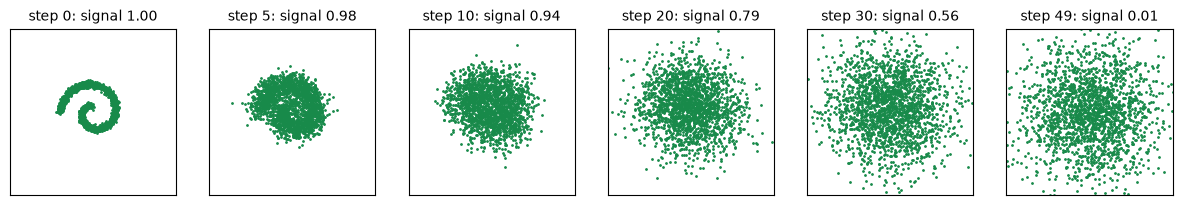

In [5]:
T = 50                                                      # number of noise steps
s = 0.008                                                   # a "cosine" noise schedule
f = np.cos(((np.arange(T + 1) / T) + s) / (1 + s) * np.pi / 2) ** 2
alpha_bar = torch.tensor(np.clip(f[1:] / f[0], 1e-4, 1), dtype=torch.float32)   # how much signal is left at each step

def add_noise(x0, t, eps):
    a = alpha_bar[t][:, None]
    return a.sqrt() * x0 + (1 - a).sqrt() * eps

class Denoiser(nn.Module):
    """Given a noisy point and the step number, guess the noise that was added."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2 + 16, 128), nn.SiLU(), nn.Linear(128, 128), nn.SiLU(),
                                 nn.Linear(128, 128), nn.SiLU(), nn.Linear(128, 2))
    def forward(self, x, t):
        freqs = torch.arange(8) + 1.0
        angle = (t[:, None].float() / T) * freqs * np.pi
        time = torch.cat([angle.sin(), angle.cos()], 1)      # the step number, as 16 smooth numbers
        return self.net(torch.cat([x, time], 1))

def train_denoiser(steps=4000, seed=0):
    torch.manual_seed(seed)
    model = Denoiser()
    opt = torch.optim.Adam(model.parameters(), lr=2e-3)
    X = torch.tensor(data, dtype=torch.float32)
    losses = []
    for step in range(steps):
        x0 = X[torch.randint(len(X), (256,))]
        t = torch.randint(T, (256,))
        eps = torch.randn_like(x0)
        loss = F.mse_loss(model(add_noise(x0, t, eps), t), eps)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    return model, losses

@torch.no_grad()
def sample(model, n=1500, seed=1, keep=()):
    g = torch.Generator().manual_seed(seed)
    x = torch.randn(n, 2, generator=g)                       # start from pure noise
    saved = {T: x.clone()}
    for t in range(T - 1, -1, -1):
        tt = torch.full((n,), t)
        eps = model(x, tt)
        a = alpha_bar[t]
        a_prev = alpha_bar[t - 1] if t > 0 else torch.tensor(1.0)
        x0_guess = (x - (1 - a).sqrt() * eps) / a.sqrt()     # undo all the noise in one guess...
        x0_guess = x0_guess.clamp(-1.5, 1.5)
        x = a_prev.sqrt() * x0_guess + (1 - a_prev).sqrt() * eps   # ...then step back to slightly less noise
        if t in keep:
            saved[t] = x.clone()
    saved[0] = x
    return x, saved

X = torch.tensor(data, dtype=torch.float32)
fig, axes = plt.subplots(1, 6, figsize=(15, 2.7))
for ax, t in zip(axes, [0, 5, 10, 20, 30, 49]):
    xt = add_noise(X[:2000], torch.full((2000,), t), torch.randn(2000, 2))
    ax.scatter(xt[:, 0], xt[:, 1], s=1, color="#188a4a")
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"step {t}: signal {alpha_bar[t].sqrt():.2f}", fontsize=10)
plt.show()

### 🤔 Predict first

To undo this, the network is trained on one job: **given a noisy point and the step number, guess the noise $\epsilon$ that was mixed in.** Why might guessing the noise be easier than guessing the clean point directly?

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

Because the noise always has the same simple shape (a bell curve, average 0, spread 1) at every step. The network's best guess is the **average** noise consistent with what it sees (an **expected value**). Subtract that, and you get the best guess of the clean point.

</details>

trained in 7s, final loss 0.265


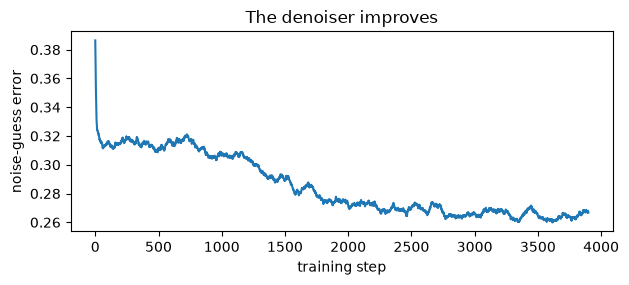

In [6]:
import time
t0 = time.time()
model, losses = train_denoiser()
print(f"trained in {time.time() - t0:.0f}s, final loss {np.mean(losses[-200:]):.3f}")
plt.figure(figsize=(7, 2.6))
plt.plot(np.convolve(losses, np.ones(100) / 100, mode="valid"))
plt.xlabel("training step"); plt.ylabel("noise-guess error"); plt.title("The denoiser improves"); plt.show()

**Generating:** start from 1,500 points of pure noise. At each step, the network guesses the noise; remove a step's worth of it; repeat 50 times.

In [7]:
from matplotlib import animation
from IPython.display import HTML

gen, saved = sample(model, keep=range(T))
fig, ax = plt.subplots(figsize=(4.5, 4.5))
def frame(k):
    t = T - 2 * k if k < T // 2 else 0
    ax.clear()
    p = saved[max(t, 0)].numpy()
    ax.scatter(p[:, 0], p[:, 1], s=2, color="#a87b00")
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{max(t, 0)} steps of noise left")
anim = animation.FuncAnimation(fig, frame, frames=T // 2 + 4, interval=150)
plt.close(fig)
HTML(anim.to_jshtml())

In [8]:
g = gen.numpy()
print(f"mismatch (KL):  Gaussian {kl(histogram(data), histogram(blob)):.3f}   "
      f"autoencoder {kl(histogram(data), histogram(new)):.3f}   diffusion {kl(histogram(data), histogram(g)):.3f}")

# new, or copies? distance from each generated point to its nearest training point
from scipy.spatial import cKDTree
nearest, _ = cKDTree(data).query(g)
train_gaps, _ = cKDTree(data[:2500]).query(data[2500:])
print(f"median distance to the nearest training point: generated {np.median(nearest):.4f}, "
      f"a fresh real point {np.median(train_gaps):.4f}")

mismatch (KL):  Gaussian 1.803   autoencoder 1.408   diffusion 0.506


median distance to the nearest training point: generated 0.0066, a fresh real point 0.0054


**What you see:** the diffusion model's points form the spiral, and its mismatch is the lowest of the three.
Generated points sit about as far from the training points as fresh real points do: they are **new samples**, not copies.

**What it's called:**
- adding noise step by step is the *forward process*; the plan of how much noise at each step is the *noise schedule*
- the network that removes it is the *denoiser*; running it from pure noise is *sampling*
- a model built this way is a *diffusion model*

## 5. The library version

The Hugging Face **diffusers** library provides noise schedules and sampling steps (its "schedulers") for image models. Plug your trained denoiser into its DDIM scheduler.

In [9]:
import warnings
warnings.filterwarnings("ignore", message=".*IProgress.*")     # a harmless notice from a progress-bar library
from diffusers import DDIMScheduler

# clip_sample keeps each "clean point" guess inside the same box as your sampler's clamp(-1.5, 1.5)
sched = DDIMScheduler(num_train_timesteps=T, beta_schedule="squaredcos_cap_v2", clip_sample=True, clip_sample_range=1.5)
sched.set_timesteps(T)
x = torch.randn(1500, 2, generator=torch.Generator().manual_seed(1))
with torch.no_grad():
    for t in sched.timesteps:
        eps = model(x, torch.full((1500,), int(t)))
        x = sched.step(eps, t, x).prev_sample
lib = x.numpy()
print(f"library schedule, your denoiser: mismatch (KL) {kl(histogram(data), histogram(lib)):.3f}")
print(f"the library's noise schedule vs yours, largest gap: {float((sched.alphas_cumprod - alpha_bar).abs().max()):.4f}")

library schedule, your denoiser: mismatch (KL) 0.517
the library's noise schedule vs yours, largest gap: 0.0001


The library's schedule matches yours closely, and your denoiser works with it unchanged. For images, the denoiser is a big network (a U-Net or a transformer) and the points have millions of numbers, but the loop is the one you wrote.

## Practice

Try each one before opening its solution.

### Exercise 1

By hand: $x_0 = (2, 0)$, $\bar\alpha = 0.25$ and the noise drawn is $\epsilon = (1, -1)$. **What is $x_t$?**

<details><summary><b>Show the answer to exercise 1</b></summary>

$\sqrt{0.25} = 0.5$, $\sqrt{0.75} \approx 0.87$. $x_t = 0.5 \times (2, 0) + 0.87 \times (1, -1) = (1.87, -0.87)$.

</details>

### Exercise 2

Generate with **fewer steps**: sample using only every 5th step (10 steps instead of 50). **How does the mismatch change?** (Hint: use the library scheduler with `sched.set_timesteps(10)`.)

In [10]:
# your code here

In [ ]:
#@title Solution to exercise 2 (double-click to show)
for n in (2, 5, 10, 25, 50):
    sched.set_timesteps(n)
    x = torch.randn(1500, 2, generator=torch.Generator().manual_seed(1))
    with torch.no_grad():
        for t in sched.timesteps:
            x = sched.step(model(x, torch.full((1500,), int(t))), t, x).prev_sample
    print(f"{n:2d} steps: mismatch {kl(histogram(data), histogram(x.numpy())):.3f}")
# Fewer steps means bigger jumps; quality falls off below about 10 steps here. Faster sampling is an open research problem.

### Exercise 3

Change the data to **two separate rings** (points on a circle of radius 0.4 and a circle of radius 1.0), retrain the denoiser, and generate. **Does it produce both rings, in the right proportions?**

In [12]:
# your code here

In [ ]:
#@title Solution to exercise 3 (double-click to show)
n = 5000
r = np.where(rng.random(n) < 0.5, 0.4, 1.0)
a = rng.uniform(0, 2 * np.pi, n)
data = np.stack([r * np.cos(a), r * np.sin(a)], 1) + rng.normal(0, 0.02, (n, 2))
model2, _ = train_denoiser()
g2, _ = sample(model2)
g2 = g2.numpy()
inner = (np.linalg.norm(g2, axis=1) < 0.7).mean()
print(f"share of generated points on the inner ring: {inner:.0%} (real: 50%)")
plt.scatter(g2[:, 0], g2[:, 1], s=1); plt.gca().set_aspect("equal"); plt.show()

## Recognition cues

- When you see **"generate new samples that look like the training data"** in a problem, think **a generative model: diffusion, an autoencoder, a Gaussian**.
- When you see **"undo a corruption a little at a time"** in a problem, think **denoising, step by step (diffusion)**.
- When you see **"how different are two distributions?"** in a problem, think **KL divergence**.
- When you see **"is the model copying its training data?"** in a problem, think **measure distances to the nearest training example**.

## Try changing this

1. **A smaller denoiser.** Change the hidden size from 128 to 16. Can it still make a spiral?
2. **Fewer noise steps in training.** Set `T = 10`. What happens to quality?
3. **Steer the output.** Give the denoiser an extra input (0 for the inner half of the spiral, 1 for the outer) and train it. Can you ask for only the outer half?

## Open research questions

People are working on these right now:

- How do we make generation faster and controllable?
- How do we detect generated content?

Any of them could become a thesis topic.

## Spark Log

Before you close this notebook, write three things about **Generative models** in your Spark Log (the Spark Log page on the site):

1. **What surprised me?**
2. **What would I want to know next?**
3. **Excitement, 1 to 10.** How much would you enjoy a year of this?

Write it now, while it's fresh. You will compare fields later.

## Go deeper

- Hugging Face diffusion models course (free): https://huggingface.co/learn/diffusion-course/en/unit0/1
- At Monash: builds on FIT5215 Deep learning and FIT5221 Intelligent image and video analysis.